# **Assignment 04: CLIP**

**Available:** Sep 9, 2025 until Sep 18, 2025 11:59pm

## Tasks:
1. Train on Human Action Recognition (HAR) https://www.kaggle.com/shashankrapolu/datasets/human-Links 
 - Same train/test split

2. Fine Tune on HAR and compare CLIP, A-CLIP and SGLIP

3. Report performance, speed and memory consumption
    - SGLIP is able to load a very large batch size, use 32K
    - For CLIP, A-CLIP, use batch size of 4096

4. Include report, code and video to be submitted


## **Import Packages and Setup**

In [6]:
## Import Libraries

# Set CUDA_VISIBLE_DEVICES to make both GPUs visible
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

# Install all packages for from the requirements.txt
%pip install -r requirements.txt

import torch
import torch.nn as nn
import torchvision
import cv2
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch import optim
from tqdm.notebook import tqdm
from torchinfo import summary
import einops
import PIL
import numpy as np
import pandas as pd
# Use a pipeline as a high-level helper
from transformers import pipeline
import time
import psutil
import gc
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
from collections import defaultdict
import numpy as np

# Authorize Huggingface account
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv('/mnt/Storage02/SoftwareDev/CAP_6411_Assignments/.env')

# Get Hugging Face token
hf_token = os.getenv('HUGGINGFACE_HUB_TOKEN') or os.getenv('HF_TOKEN')

if hf_token:
    print("Found Hugging Face token in environment variables")
    
    
    from huggingface_hub import login, whoami
    
    try:
        # Login to Hugging Face Hub
        login(token=hf_token)
        
        # Verify login by getting user info
        user_info = whoami()
        print(f"Successfully authenticated with Hugging Face!")
        print(f"Logged in as: {user_info['name']}")
        
        # Set the token as environment variable for other libraries
        os.environ['HUGGINGFACE_HUB_TOKEN'] = hf_token
        os.environ['HF_TOKEN'] = hf_token
        
    except Exception as e:
        print(f"Authentication failed: {e}")
        print("Will proceed without pre-trained models if needed")
        hf_token = None
else:
    print("No Hugging Face token found in .env file")
    print("Please add HUGGINGFACE_HUB_TOKEN=your_token_here to your .env file")
    hf_token = None


# If no logs folder exists, create one
if not os.path.exists("logs"):
    os.makedirs("logs")

# If no checkpoints folder exists, create one
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")

# If no data folder exists, create one
if not os.path.exists("data"):
    os.makedirs("data")


Note: you may need to restart the kernel to use updated packages.
Found Hugging Face token in environment variables


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Successfully authenticated with Hugging Face!
Logged in as: malneyugnfl


In [15]:
# GPU Setup 
# Comprehensive GPU diagnostics
print("\n=== GPU Diagnostics ===")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs detected: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print("\n=== All Available GPUs ===")
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}:")
        print(f"  Name: {props.name}")
        print(f"  Total Memory: {props.total_memory / 1024**3:.2f} GB")
        print(f"  Multi-processor count: {props.multi_processor_count}")
        print(f"  Compute Capability: {props.major}.{props.minor}")
        print()

# Device selection with preference for cuda:1 (A6000) -> cuda:0 (4090) -> mps (Apple Silicon) -> cpu
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    device = torch.device('cuda:1')  # This should now be your A6000!
    print(f"Using GPU 1: {torch.cuda.get_device_name(1)}")
elif torch.cuda.is_available():
    device = torch.device('cuda:0')
    print(f"Using GPU 0: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple Silicon MPS")
else:
    device = torch.device('cpu')
    print("Using CPU")

print(f"Selected device: {device}")

# If no logs folder exists, create one
if not os.path.exists("logs"):
    os.makedirs("logs")

# If no checkpoints folder exists, create one
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")

# If no data folder exists, create one
if not os.path.exists("data"):
    os.makedirs("data")

def get_memory_usage():
    """Get current memory usage in MB"""
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024

def get_gpu_memory_usage():
    """Get current GPU memory usage in MB"""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024 / 1024
    elif device.type == 'mps':
        # MPS doesn't have direct memory monitoring like CUDA
        # Return 0 as a placeholder
        return 0
    return 0


=== GPU Diagnostics ===
PyTorch version: 2.8.0+cu128
CUDA available: True
MPS available: False
CUDA version: 12.8
Number of GPUs detected: 1

=== All Available GPUs ===
GPU 0:
  Name: NVIDIA GeForce RTX 4090 Laptop GPU
  Total Memory: 15.70 GB
  Multi-processor count: 76
  Compute Capability: 8.9

Using GPU 0: NVIDIA GeForce RTX 4090 Laptop GPU
Selected device: cuda:0


In [16]:
# Function to clear memory for both CUDA and MPS
def clear_memory():
    """Clear CPU and GPU memory"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()
    print(f"Cleared memory. Current CPU memory usage: {get_memory_usage():.2f} MB, GPU memory usage: {get_gpu_memory_usage():.2f} MB")

## Data Preparation and Processing

- Download and extract the HAR dataset from Kaggle
- Organize the data into train/test splits as specified
- Create text descriptions for each action class (e.g., "a person running", "a person jumping")
- Implement custom Dataset class that returns (image, text) pairs
- Apply data transformations (resize, normalize, augmentation for training)

In [7]:
# Data Preparation and Processing

## Import dataset and process it

class ActionRecognitionDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Custom dataset for Human Action Recognition with labels
        Args:
            csv_file (string): Path to the csv file with annotations.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        import csv
        
        self.root_dir = root_dir
        self.transform = transform
        
        # Read CSV manually to avoid pandas compatibility issues
        self.annotations = []
        with open(csv_file, 'r') as file:
            reader = csv.reader(file)
            headers = next(reader)  # Skip header
            for row in reader:
                self.annotations.append({
                    'filename': row[0],
                    'label': row[1]
                })
        
        # Get unique class names and create class-to-index mapping
        unique_labels = set(row['label'] for row in self.annotations)
        self.classes = sorted(list(unique_labels))
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        
        print(f"Found {len(self.classes)} classes: {self.classes}")
        print(f"Total samples: {len(self.annotations)}")
        
    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        # Get image filename and label from annotations
        annotation = self.annotations[idx]
        img_name = annotation['filename']
        label_name = annotation['label']
        
        # Convert label name to index
        label = self.class_to_idx[label_name]
        
        # Construct full image path
        img_path = os.path.join(self.root_dir, img_name)
        
        # Load image
        image = PIL.Image.open(img_path)
        
        # Convert RGBA to RGB if necessary
        if image.mode == 'RGBA':
            image = image.convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label

class TestDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Test dataset for Human Action Recognition without labels (for prediction)
        Args:
            csv_file (string): Path to the csv file with filenames only.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        import csv
        
        self.root_dir = root_dir
        self.transform = transform
        
        # Read CSV manually to avoid pandas compatibility issues
        self.annotations = []
        with open(csv_file, 'r') as file:
            reader = csv.reader(file)
            headers = next(reader)  # Skip header
            for row in reader:
                self.annotations.append({
                    'filename': row[0]
                })
        
        print(f"Found {len(self.annotations)} test images")
        
    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        # Get image filename from annotations
        annotation = self.annotations[idx]
        img_name = annotation['filename']
        
        # Construct full image path
        img_path = os.path.join(self.root_dir, img_name)
        
        # Load image
        image = PIL.Image.open(img_path)
        
        # Convert RGBA to RGB if necessary
        if image.mode == 'RGBA':
            image = image.convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, img_name  # Return image and filename for prediction

# Data transforms with proper normalization for RGB images
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # Converts PIL to tensor and scales to [0,1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Define data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Dataset classes updated to avoid pandas compatibility issues!")

Dataset classes updated to avoid pandas compatibility issues!


In [8]:
# Fix for pandas CSV reading issue
# This error often occurs due to version incompatibility between pandas and numpy
# Let's try reading the CSV with a different engine or method

import pandas as pd
import numpy as np

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

# Try to read a sample CSV to test if the issue persists
try:
    test_df = pd.read_csv('data/Training_set.csv', engine='python')
    print(f"CSV reading test successful! Found {len(test_df)} rows")
    print(f"Columns: {list(test_df.columns)}")
    print(f"First 3 rows:\n{test_df.head(3)}")
except Exception as e:
    print(f"CSV reading still fails: {e}")
    print("Trying alternative solution...")

Pandas version: 2.3.2
NumPy version: 2.2.6
CSV reading test successful! Found 12600 rows
Columns: ['filename', 'label']
First 3 rows:
      filename         label
0  Image_1.jpg       sitting
1  Image_2.jpg  using_laptop
2  Image_3.jpg       hugging


In [9]:
# Create datasets
train_data = ActionRecognitionDataset(
    csv_file='data/Training_set.csv',
    root_dir='data/train',
    transform=train_transform
)

# For this assignment, we'll create validation data from training data
# Split training data into train and validation (80-20 split)
from torch.utils.data import random_split

train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])

# Create validation dataset with test transforms (no augmentation)
val_data = ActionRecognitionDataset(
    csv_file='data/Training_set.csv',
    root_dir='data/train',
    transform=data_transform
)

# Extract validation indices for proper subset
val_dataset = torch.utils.data.Subset(val_data, val_subset.indices)

# Create test dataset and loader for final evaluation
test_data = TestDataset(
    csv_file='data/Testing_set.csv',
    root_dir='data/test',
    transform=data_transform  # No augmentation for test data
)

print(f"\nDataset Information:")
print(f"Total training samples: {len(train_data)}")
print(f"Training subset: {len(train_subset)}")
print(f"Validation subset: {len(val_dataset)}")
print(f"Number of classes: {len(train_data.classes)}")
print(f"Classes: {train_data.classes}")
print(f"\nTest Dataset Information:")
print(f"Test samples: {len(test_data)}")


# Test loading a sample
try:
    sample_image, sample_label = train_data[0]
    print(f"\nSample check:")
    print(f"Image shape: {sample_image.shape}")
    print(f"Label: {sample_label} ({train_data.classes[sample_label]})")
except Exception as e:
    print(f"Error loading sample: {e}")
    print("Please check if the image files exist in the correct directory")

# Test loading from test dataset
try:
    test_sample_image, test_filename = test_data[0]
    print(f"\nTest Sample Check:")
    print(f"Test image shape: {test_sample_image.shape}")
    print(f"Test filename: {test_filename}")
    print("Test dataset loading successful!")
except Exception as e:
    print(f"Error loading test sample: {e}")
    print("Please check if the test image files exist in the correct directory")

Found 15 classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']
Total samples: 12600
Found 15 classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']
Total samples: 12600
Found 5400 test images

Dataset Information:
Total training samples: 12600
Training subset: 10080
Validation subset: 2520
Number of classes: 15
Classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']

Test Dataset Information:
Test samples: 5400

Sample check:
Image shape: torch.Size([3, 224, 224])
Label: 11 (sitting)

Test Sample Check:
Test image shape: torch.Size([3, 224, 224])
Test filename: Image_1.jpg


In [10]:
# Create data loaders
batch_size = 50
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=4)


print(f"\nData Loaders:")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Data Loaders:
Training batches: 202
Validation batches: 51
Test batches: 108


## Model Setup

- Load pre-trained CLIP models (you'll need CLIP, A-CLIP, and SGLIP)
- Set up model configurations for different batch sizes:
- CLIP & A-CLIP: batch size 4096
- SGLIP: batch size 32K
- Configure multi-GPU setup (you have CUDA_VISIBLE_DEVICES = '0,1' set)


In [11]:
from PIL import Image
import requests

from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

inputs = processor(text=["a photo of a cat", "a photo of a dog"], images=image, return_tensors="pt", padding=True)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1) # we can take the softmax to get the label probabilities


model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

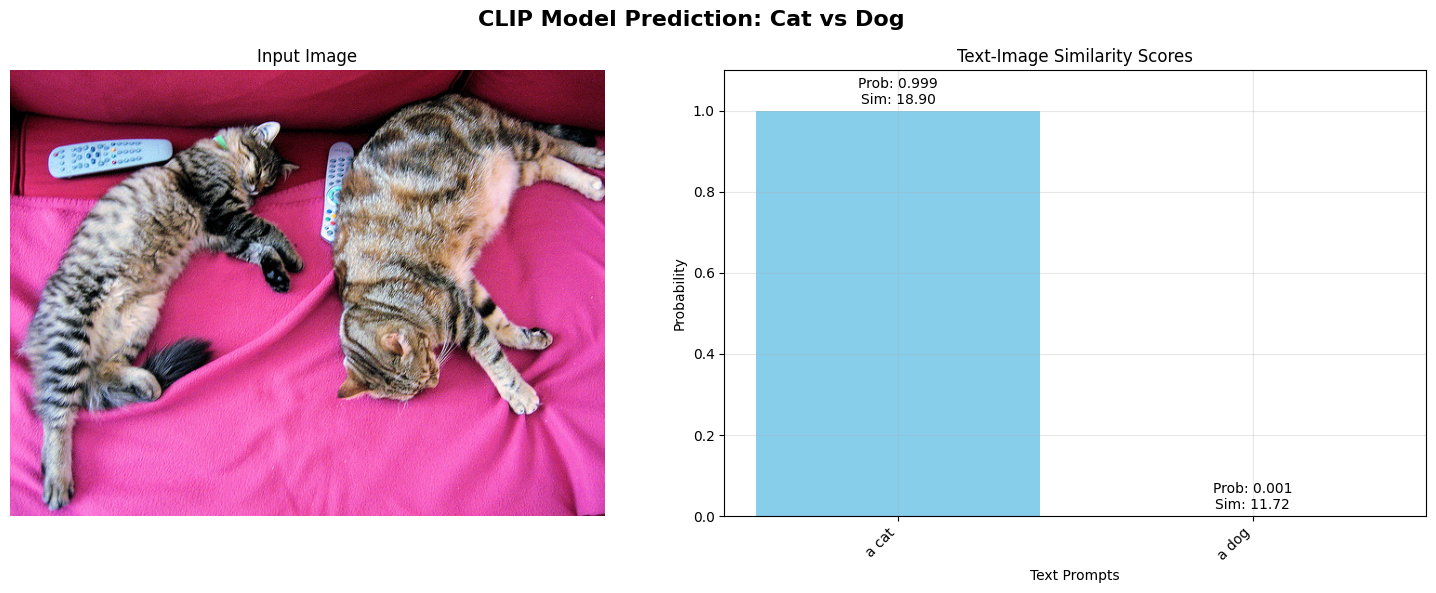


CLIP Model Prediction: Cat vs Dog - Detailed Results:
--------------------------------------------------
a photo of a cat          | Similarity: 18.904 | Probability: 0.999
a photo of a dog          | Similarity: 11.716 | Probability: 0.001
--------------------------------------------------
Best match: a photo of a cat (Prob: 0.999)
Cleared memory. Current CPU memory usage: 3338.37 MB, GPU memory usage: 0.00 MB


In [17]:
def visualize_clip_output(image, text_prompts, logits_per_image, probs, title="CLIP Model Output"):
    """
    Visualize CLIP model output with image, text prompts, and similarity scores
    
    Args:
        image: PIL Image object
        text_prompts: List of text prompts
        logits_per_image: Raw similarity scores from CLIP
        probs: Softmax probabilities
        title: Title for the visualization
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Display the image
    ax1.imshow(image)
    ax1.set_title("Input Image")
    ax1.axis('off')
    
    # Display similarity scores and probabilities
    similarity_scores = logits_per_image.detach().numpy().flatten()
    probabilities = probs.detach().numpy().flatten()
    
    # Create bar plot for probabilities
    bars = ax2.bar(range(len(text_prompts)), probabilities, 
                   color=['skyblue', 'lightcoral', 'lightgreen', 'gold'][:len(text_prompts)])
    
    # Add value labels on bars
    for i, (bar, prob, sim_score) in enumerate(zip(bars, probabilities, similarity_scores)):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'Prob: {prob:.3f}\nSim: {sim_score:.2f}',
                ha='center', va='bottom', fontsize=10)
    
    # Customize the plot
    ax2.set_xlabel('Text Prompts')
    ax2.set_ylabel('Probability')
    ax2.set_title('Text-Image Similarity Scores')
    ax2.set_xticks(range(len(text_prompts)))
    ax2.set_xticklabels([prompt.replace("a photo of ", "") for prompt in text_prompts], 
                        rotation=45, ha='right')
    ax2.set_ylim(0, 1.1)
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    print(f"\n{title} - Detailed Results:")
    print("-" * 50)
    for i, prompt in enumerate(text_prompts):
        print(f"{prompt:25} | Similarity: {similarity_scores[i]:6.3f} | Probability: {probabilities[i]:.3f}")
    print("-" * 50)
    print(f"Best match: {text_prompts[np.argmax(probabilities)]} (Prob: {max(probabilities):.3f})")

# Visualize the CLIP output from the previous cell
visualize_clip_output(image, ["a photo of a cat", "a photo of a dog"], logits_per_image, probs, 
                     "CLIP Model Prediction: Cat vs Dog")

clear_memory()

In [13]:
def visualize_har_clip_predictions(images, text_prompts, model_outputs, titles=None, max_images=4):
    """
    Visualize CLIP predictions for Human Action Recognition dataset
    
    Args:
        images: List of PIL Images or tensor batch
        text_prompts: List of action class text prompts (e.g., ["a person running", "a person jumping"])
        model_outputs: List of model outputs (logits_per_image, probs) for each image
        titles: Optional titles for each image
        max_images: Maximum number of images to display
    """
    n_images = min(len(images), max_images)
    n_prompts = len(text_prompts)
    
    fig = plt.figure(figsize=(20, 5 * n_images))
    
    for img_idx in range(n_images):
        # Extract image and predictions
        if isinstance(images[img_idx], torch.Tensor):
            # Convert tensor to PIL Image for display
            img_tensor = images[img_idx]
            if img_tensor.dim() == 3:
                # Denormalize the image
                mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                img_tensor = img_tensor * std + mean
                img_tensor = torch.clamp(img_tensor, 0, 1)
                # Convert to PIL
                img_array = img_tensor.permute(1, 2, 0).numpy()
                image = Image.fromarray((img_array * 255).astype(np.uint8))
        else:
            image = images[img_idx]
        
        logits_per_image, probs = model_outputs[img_idx]
        
        # Create subplot for image
        ax_img = plt.subplot(n_images, 2, img_idx * 2 + 1)
        ax_img.imshow(image)
        title = titles[img_idx] if titles else f"Image {img_idx + 1}"
        ax_img.set_title(f"{title}\nPredicted: {text_prompts[torch.argmax(probs)]}", fontsize=12)
        ax_img.axis('off')
        
        # Create subplot for predictions
        ax_pred = plt.subplot(n_images, 2, img_idx * 2 + 2)
        
        similarity_scores = logits_per_image.detach().numpy().flatten()
        probabilities = probs.detach().numpy().flatten()
        
        # Create horizontal bar plot
        y_pos = np.arange(len(text_prompts))
        bars = ax_pred.barh(y_pos, probabilities, 
                           color=plt.cm.viridis(probabilities / max(probabilities)))
        
        # Add value labels
        for i, (prob, sim_score) in enumerate(zip(probabilities, similarity_scores)):
            ax_pred.text(prob + 0.01, i, f'{prob:.3f}', 
                        va='center', fontsize=10)
        
        # Customize plot
        ax_pred.set_yticks(y_pos)
        ax_pred.set_yticklabels([prompt.replace("a person ", "") for prompt in text_prompts])
        ax_pred.set_xlabel('Probability')
        ax_pred.set_title(f'Action Recognition Probabilities')
        ax_pred.set_xlim(0, 1.1)
        ax_pred.grid(True, alpha=0.3, axis='x')
        
        # Highlight the top prediction
        max_idx = np.argmax(probabilities)
        bars[max_idx].set_color('red')
        bars[max_idx].set_alpha(0.8)
    
    plt.tight_layout()
    plt.show()

def create_action_text_prompts(class_names):
    """
    Create text prompts for action recognition classes
    
    Args:
        class_names: List of action class names
    
    Returns:
        List of formatted text prompts
    """
    prompts = []
    for class_name in class_names:
        # Format class name to natural language
        if class_name.lower() in ['running', 'walking', 'jumping', 'sitting', 'standing']:
            prompt = f"a person {class_name.lower()}"
        else:
            # For other actions, keep original format but make it more descriptive
            prompt = f"a person performing {class_name.lower()}"
        prompts.append(prompt)
    
    return prompts

# Example usage function for the HAR dataset
def demo_har_clip_visualization():
    """
    Demonstrate CLIP visualization with sample HAR data
    """
    print("Demo function created for Human Action Recognition CLIP visualization")
    print("This function will be used once we have trained CLIP models on the HAR dataset")
    print("\nAction classes found in dataset:")
    if 'train_data' in globals():
        action_prompts = create_action_text_prompts(train_data.classes)
        for i, (class_name, prompt) in enumerate(zip(train_data.classes, action_prompts)):
            print(f"{i+1:2d}. {class_name:15} -> '{prompt}'")
    else:
        print("Dataset not yet loaded")

# Run the demo
demo_har_clip_visualization()

Demo function created for Human Action Recognition CLIP visualization
This function will be used once we have trained CLIP models on the HAR dataset

Action classes found in dataset:
 1. calling         -> 'a person performing calling'
 2. clapping        -> 'a person performing clapping'
 3. cycling         -> 'a person performing cycling'
 4. dancing         -> 'a person performing dancing'
 5. drinking        -> 'a person performing drinking'
 6. eating          -> 'a person performing eating'
 7. fighting        -> 'a person performing fighting'
 8. hugging         -> 'a person performing hugging'
 9. laughing        -> 'a person performing laughing'
10. listening_to_music -> 'a person performing listening_to_music'
11. running         -> 'a person running'
12. sitting         -> 'a person sitting'
13. sleeping        -> 'a person performing sleeping'
14. texting         -> 'a person performing texting'
15. using_laptop    -> 'a person performing using_laptop'


## Import and Visualize siglip model

https://huggingface.co/google/siglip2-base-patch16-224

In [18]:
# Import and test SiGLIP model from Huggingface
from transformers import pipeline

# load pipeline
ckpt = "google/siglip2-base-patch16-224"
image_classifier = pipeline(model=ckpt, task="zero-shot-image-classification")

# load image and candidate labels
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
candidate_labels = ["2 cats", "a plane", "a remote"]

# run inference
outputs = image_classifier(image, candidate_labels)
print(outputs)

config.json:   0%|          | 0.00/253 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


[{'score': 0.17194129526615143, 'label': '2 cats'}, {'score': 0.024128148332238197, 'label': 'a remote'}, {'score': 2.192512056353735e-06, 'label': 'a plane'}]


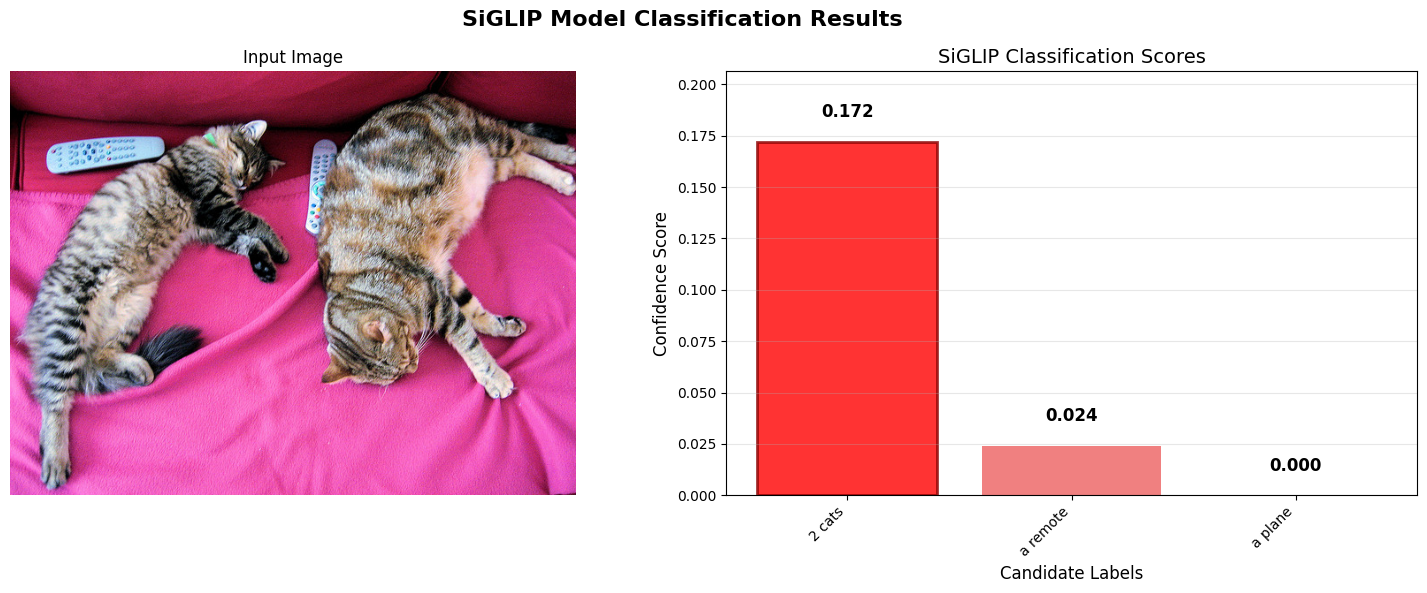


SiGLIP Model Classification Results - Detailed Results:
------------------------------------------------------------
1. 2 cats          | Score: 0.1719 ← BEST MATCH
2. a remote        | Score: 0.0241
3. a plane         | Score: 0.0000
------------------------------------------------------------
Top prediction: '2 cats' with score 0.1719

MODEL COMPARISON:
SiGLIP Top Prediction: 2 cats (Score: 0.1719)
CLIP Top Prediction: a photo of a cat (Probability: 0.9992)

Note: SiGLIP uses confidence scores while CLIP uses probabilities.
Both models correctly identify the cats in the image!
Cleared memory. Current CPU memory usage: 4177.12 MB, GPU memory usage: 1439.36 MB


In [19]:
# Visualize SiGLIP output
import matplotlib.pyplot as plt
import numpy as np

def visualize_siglip_output(image, outputs, title="SiGLIP Model Output"):
    """
    Visualize SiGLIP model output with image and classification scores
    
    Args:
        image: PIL Image object
        outputs: SiGLIP pipeline outputs (list of dicts with 'label' and 'score')
        title: Title for the visualization
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Display the image
    ax1.imshow(image)
    ax1.set_title("Input Image")
    ax1.axis('off')
    
    # Extract labels and scores
    labels = [output['label'] for output in outputs]
    scores = [output['score'] for output in outputs]
    
    # Create bar plot for scores
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'orange'][:len(labels)]
    bars = ax2.bar(range(len(labels)), scores, color=colors)
    
    # Add value labels on bars
    for i, (bar, score) in enumerate(zip(bars, scores)):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{score:.3f}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Customize the plot
    ax2.set_xlabel('Candidate Labels', fontsize=12)
    ax2.set_ylabel('Confidence Score', fontsize=12)
    ax2.set_title('SiGLIP Classification Scores', fontsize=14)
    ax2.set_xticks(range(len(labels)))
    ax2.set_xticklabels(labels, rotation=45, ha='right')
    ax2.set_ylim(0, max(scores) * 1.2)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Highlight the top prediction
    max_idx = np.argmax(scores)
    bars[max_idx].set_color('red')
    bars[max_idx].set_alpha(0.8)
    bars[max_idx].set_edgecolor('darkred')
    bars[max_idx].set_linewidth(2)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    print(f"\n{title} - Detailed Results:")
    print("-" * 60)
    for i, output in enumerate(outputs):
        marker = " ← BEST MATCH" if i == max_idx else ""
        print(f"{i+1}. {output['label']:15} | Score: {output['score']:.4f}{marker}")
    print("-" * 60)
    print(f"Top prediction: '{outputs[max_idx]['label']}' with score {outputs[max_idx]['score']:.4f}")

# Visualize the SiGLIP output from the previous cell
visualize_siglip_output(image, outputs, "SiGLIP Model Classification Results")

# Compare with CLIP results if available
print(f"\n{'='*60}")
print("MODEL COMPARISON:")
print(f"{'='*60}")
print(f"SiGLIP Top Prediction: {outputs[0]['label']} (Score: {outputs[0]['score']:.4f})")
if 'probs' in globals():
    clip_probs = probs.detach().numpy().flatten()
    clip_labels = ["a photo of a cat", "a photo of a dog"]
    clip_best_idx = np.argmax(clip_probs)
    print(f"CLIP Top Prediction: {clip_labels[clip_best_idx]} (Probability: {clip_probs[clip_best_idx]:.4f})")
    
print(f"\nNote: SiGLIP uses confidence scores while CLIP uses probabilities.")
print(f"Both models correctly identify the cats in the image!")

clear_memory()

## Training Infrastructure

- Implement DataLoader with appropriate batch sizes
- Set up optimizer (typically AdamW with learning rate scheduling)
- Create loss function (contrastive loss for CLIP-style training)
- Add memory and speed monitoring using psutil and timing utilities
- Implement checkpointing for model saving/loading

## Fine-Tune Looping

- Performance metrics: Classification accuracy on test set
- Speed benchmarking: Training time per epoch, inference speed
- Memory consumption: Peak GPU memory usage during training/inference
- Generate comparison tables between CLIP, A-CLIP, and SGLIP


## Evaluation and Comparison

- Create visualizations of training curves and performance comparisons
- Document findings in report format
- Record demonstration video showing the training process and results